## Q16

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan


def regressao_linear_normal(X, y):
    X = np.asarray(X).ravel()
    y = np.asarray(y).ravel()

    A = sm.add_constant(X)
    modelo = sm.OLS(y, A).fit()

    return modelo

In [2]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([2.2, 4.1, 5.7, 8.4, 9.5, 12.8, 13.5, 17.1, 17.8, 21.0])

modelo = regressao_linear_normal(X, y)
b0, b1 = modelo.params
print(f"Reta: y = {b0:.3f} + {b1:.3f} * x")

Reta: y = -0.147 + 2.065 * x


In [3]:
y_ajustado = modelo.predict(sm.add_constant(X))
y_ajustado

array([ 1.91818182,  3.9830303 ,  6.04787879,  8.11272727, 10.17757576,
       12.24242424, 14.30727273, 16.37212121, 18.4369697 , 20.50181818])

In [4]:
residuos = modelo.resid
residuos

array([ 0.28181818,  0.1169697 , -0.34787879,  0.28727273, -0.67757576,
        0.55757576, -0.80727273,  0.72787879, -0.6369697 ,  0.49818182])

In [5]:
epr = modelo.mse_resid
epr

np.float64(0.3627575757575767)

In [6]:
r2 = modelo.rsquared
r2

np.float64(0.9918170906838575)

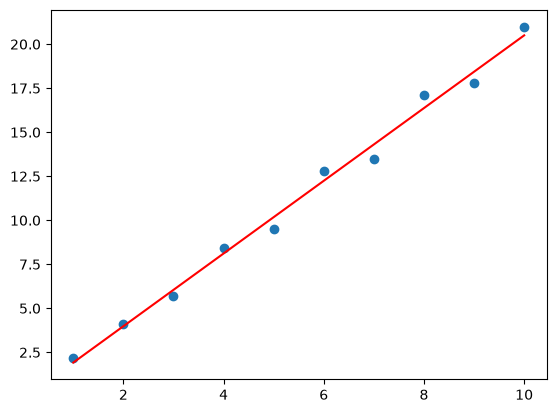

In [7]:
plt.plot(X, y, 'o')
plt.plot(X, y_ajustado, 'r-')
plt.show()

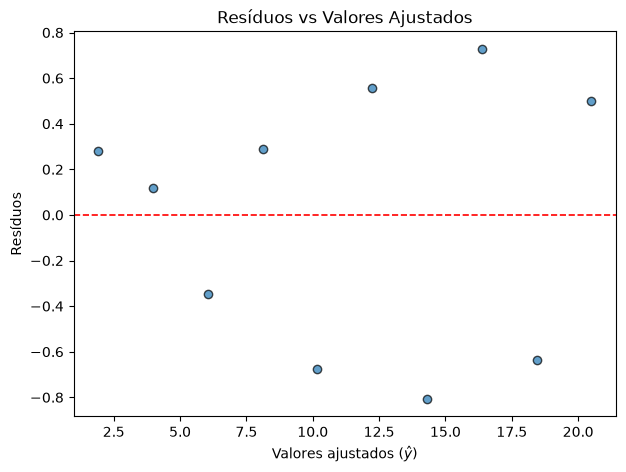

In [8]:
def plot_residuos_vs_ajustados(y_ajustado, residuos, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(y_ajustado, residuos, alpha=0.7, edgecolor='k')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Valores ajustados ($\\hat{y}$)')
    ax.set_ylabel('Resíduos')
    ax.set_title('Resíduos vs Valores Ajustados')
    return ax

plot_residuos_vs_ajustados(y_ajustado, residuos)
plt.show()


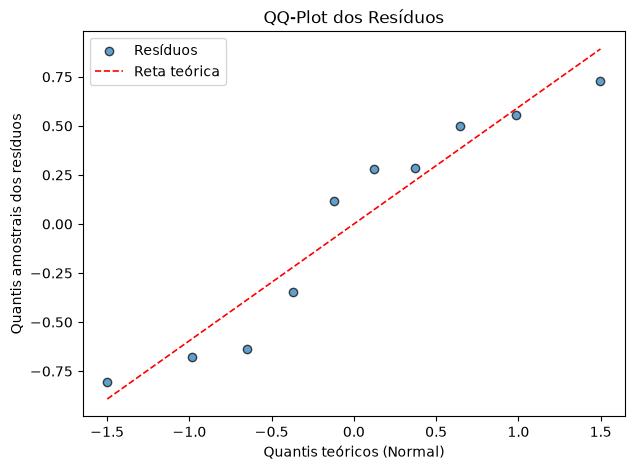

In [9]:
def plot_qq_residuos(residuos, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    (osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
    ax.scatter(osm, osr, alpha=0.7, edgecolor='k', label='Resíduos')
    ax.plot(osm, slope * osm + intercept, color='red', linestyle='--',
            linewidth=1.2, label='Reta teórica')
    ax.set_xlabel('Quantis teóricos (Normal)')
    ax.set_ylabel('Quantis amostrais dos resíduos')
    ax.set_title(f'QQ-Plot dos Resíduos')
    ax.legend()
    return ax

plot_qq_residuos(residuos)
plt.show()

In [10]:
residuos_padronizados = modelo.resid_pearson
residuos_padronizados

array([ 0.46790832,  0.19420711, -0.57759005,  0.47696461, -1.12499247,
        0.92575409, -1.34033092,  1.20851158, -1.05757342,  0.82714115])

In [11]:
influencia = modelo.get_influence()

leverage = influencia.hat_matrix_diag
leverage

array([0.34545455, 0.24848485, 0.17575758, 0.12727273, 0.1030303 ,
       0.1030303 , 0.12727273, 0.17575758, 0.24848485, 0.34545455])

In [12]:
dist_cook, p_valores_cook = influencia.cooks_distance

In [13]:
limiar = 4 / dist_cook.size
idx = np.where(dist_cook > limiar)[0]

pontos_influentes = (idx, dist_cook[idx], limiar)
pontos_influentes

(array([], dtype=int64), array([], dtype=float64), 0.4)

### Diagnóstico 

- **Ajuste:** y = -0.147 + 2.065 * x, com R2 = 0.992. A inclinação é significativa

- **Linearidade:** sem curvatura nos resíduos. A forma linear é adequada. (Olhando pelo residuosXajustados)
- **Homocedasticidade:** os resíduos crescem com os valores ajustados. Há heterocedasticidade.

- **Independência:** os resíduos alternam de sinal alternadamente, possivel autocorrelação.

- **Normalidade:** não rejeitada pelo qqplot, mas com n = 10 o teste é fraco.
- **Pontos influentes:** nenhum outlier; nenhum ponto passa do limiar da distância de Cook (4/n = 0.4).  

**Conclusão:** a reta descreve bem a tendência e os coeficientes não são viesados, mas a heterocedasticidade e a autocorrelação tornam os erros-padrão e os p-valores pouco confiáveis. Uma opção é usar erros-padrão robustos ou MQP.

## 17

In [ ]:

np.random.seed(42)

n = 150
X = np.random.uniform(1, 10, n)

# epz muda de acordo com X
epsilon = np.random.normal(
    loc=0,
    scale=0.3 * X,
    size=n
)

Y = 3 + 2 * X + epsilon

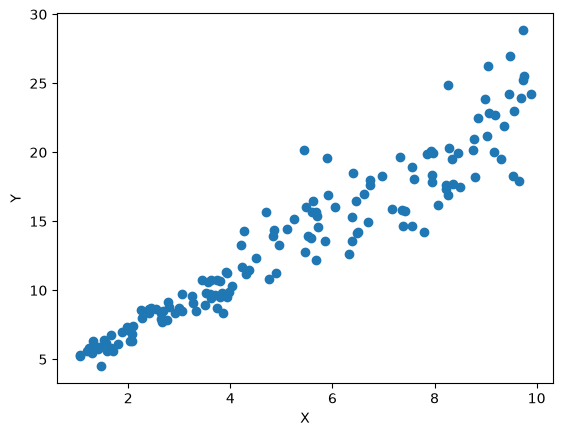

In [15]:
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Reta: y = 2.825 + 2.055 * x


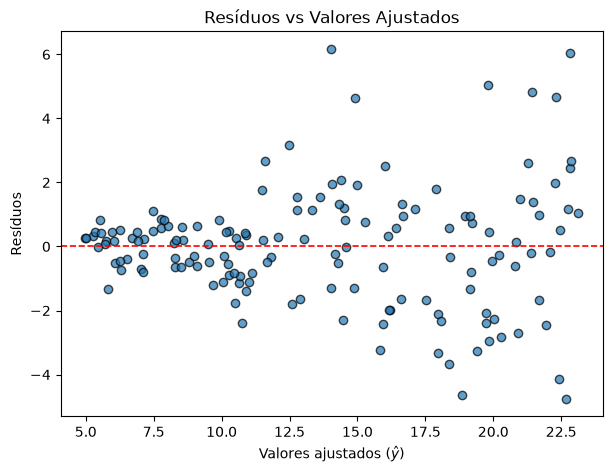

In [ ]:
modelo_17 = regressao_linear_normal(X, Y)
b0_17, b1_17 = modelo_17.params
print(f"Reta: y = {b0_17:.3f} + {b1_17:.3f} * x")

plot_residuos_vs_ajustados(modelo_17.fittedvalues, modelo_17.resid)
plt.show()

In [ ]:
A17 = sm.add_constant(X)
pesos = 1 / X**2

modelo_mqp = sm.WLS(Y, A17, weights=pesos).fit()
modelo_mqp_c = sm.WLS(Y, A17, weights=5 * pesos).fit()

print(f"Pesos 1/X²: b0 = {modelo_mqp.params[0]:.4f}, b1 = {modelo_mqp.params[1]:.4f}, "
      f"EP = {modelo_mqp.bse.round(4)}, sigma² = {modelo_mqp.scale:.4f}")
print(f"Pesos 5/X²: b0 = {modelo_mqp_c.params[0]:.4f}, b1 = {modelo_mqp_c.params[1]:.4f}, "
      f"EP = {modelo_mqp_c.bse.round(4)}, sigma² = {modelo_mqp_c.scale:.4f}")

Pesos 1/X²: b0 = 2.9763, b1 = 2.0205, EP = [0.1307 0.0438], sigma² = 0.0965
Pesos 5/X²: b0 = 2.9763, b1 = 2.0205, EP = [0.1307 0.0438], sigma² = 0.4823


**b) Por que o fator constante omitido não altera os coeficientes**

A variância do erro é proporcional a X ao quadrado, vezes uma constante desconhecida. Usar pesos 1/X^2 é o mesmo que omitir essa constante.

Multiplicar todos os pesos por uma mesma constante não muda os coeficientes, porque ela se cancela na fórmula do MQP: o método depende só dos pesos relativos entre as observações. A constante vai para a variância residual estimada (0.0965 com pesos 1/X^2, 0.4823 com 5/X^2), o que compensa no cálculo dos erros-padrão. Por isso eles também não mudam.

    MQO coef  MQO EP  MQP coef  MQP EP
b0    2.8246  0.3308    2.9763  0.1307
b1    2.0553  0.0562    2.0205  0.0438

MQO - resíduos brutos          0.0000
MQP - resíduos brutos          0.0000
MQP - resíduos padronizados    0.9234
Name: p-valor BP, dtype: float64


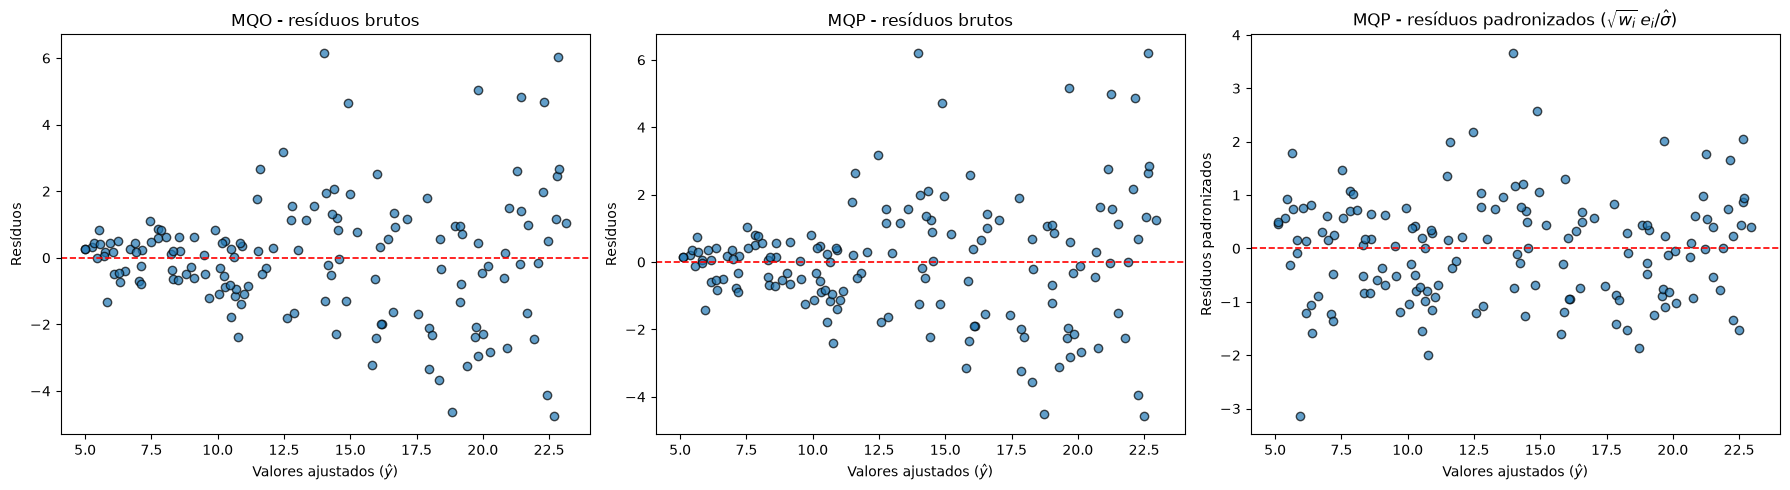

In [18]:
comparacao = pd.DataFrame({
    'MQO coef': modelo_17.params,
    'MQO EP':   modelo_17.bse,
    'MQP coef': modelo_mqp.params,
    'MQP EP':   modelo_mqp.bse,
}, index=['b0', 'b1'])
print(comparacao.round(4), end='\n\n')

bp = pd.Series({
    'MQO - resíduos brutos':       het_breuschpagan(modelo_17.resid, A17)[1],
    'MQP - resíduos brutos':       het_breuschpagan(modelo_mqp.resid, A17)[1],
    'MQP - resíduos padronizados': het_breuschpagan(modelo_mqp.resid_pearson, A17)[1],
}, name='p-valor BP')
print(bp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
plot_residuos_vs_ajustados(modelo_17.fittedvalues, modelo_17.resid, ax=axes[0])
axes[0].set_title('MQO - resíduos brutos')
plot_residuos_vs_ajustados(modelo_mqp.fittedvalues, modelo_mqp.resid, ax=axes[1])
axes[1].set_title('MQP - resíduos brutos')
plot_residuos_vs_ajustados(modelo_mqp.fittedvalues, modelo_mqp.resid_pearson, ax=axes[2])
axes[2].set_title('MQP - resíduos padronizados ($\\sqrt{w_i}\\,e_i / \\hat\\sigma$)')
axes[2].set_ylabel('Resíduos padronizados')
plt.tight_layout()
plt.show()

- Estimativas: os dois ajustes ficam perto dos valores verdadeiros (3 e 2)
- Erros-padrão: o MQP tem erros menores, porque dá mais peso às observações menos ruidosas. O erro-padrão clássico do MQO é inválido, porque supõe variância constante.
- Diagnósticos: no MQO os resíduos formam um funil. No MQP, os resíduos padronizados formam uma faixa constante: os pesos corrigiram a heterocedasticidade.

In [ ]:
modelo_hc3 = modelo_17.get_robustcov_results(cov_type='HC3')

inferencia = pd.DataFrame({
    'coef':         np.r_[modelo_17.params, modelo_hc3.params, modelo_mqp.params],
    'EP':           np.r_[modelo_17.bse, modelo_hc3.bse, modelo_mqp.bse],
    'IC 95% inf':   np.r_[modelo_17.conf_int()[:, 0], modelo_hc3.conf_int()[:, 0], modelo_mqp.conf_int()[:, 0]],
    'IC 95% sup':   np.r_[modelo_17.conf_int()[:, 1], modelo_hc3.conf_int()[:, 1], modelo_mqp.conf_int()[:, 1]],
    'p-valor':      np.r_[modelo_17.pvalues, modelo_hc3.pvalues, modelo_mqp.pvalues],
}, index=pd.MultiIndex.from_product([['MQO clássico', 'MQO HC3', 'MQP'], ['b0', 'b1']]))
inferencia.round(4)

coef      EP  IC 95% inf  IC 95% sup  p-valor
MQO clássico b0  2.8246  0.3308      2.1709      3.4784      0.0
             b1  2.0553  0.0562      1.9443      2.1662      0.0
MQO HC3      b0  2.8246  0.2421      2.3462      3.3031      0.0
             b1  2.0553  0.0627      1.9313      2.1792      0.0
MQP          b0  2.9763  0.1307      2.7181      3.2346      0.0
             b1  2.0205  0.0438      1.9339      2.1071      0.0

d)

O HC3 mantém os coeficientes do MQO e corrige só os erros-padrão.

- **Inclinação:** o erro-padrão sobe. O MQO clássico subestimava a incerteza.
- **Intercepto:** o erro-padrão cai. O MQO clássico superestimava a incerteza.
- **Testes:** todos os coeficientes seguem significativos, mas só os intervalos robustos são confiáveis.
- **HC3 contra MQP:** o HC3 não exige saber a forma da variância, mas continua com o estimador MQO, menos eficiente. O MQP dá erros menores, desde que os pesos estejam corretos.

e)

O MQP muda a forma de estimar os coeficientes, não os dados. O resíduo bruto continua refletindo o erro original, cuja variância cresce com X. Por isso os resíduos brutos do MQP ainda formam um funil. Isso não quer dizer que o modelo falhou.

Para avaliar o modelo ponderado, resíduos que incorporam os pesos:

- **Ponderados:** resíduo vezes a raiz do peso, ou seja, resíduo dividido por X 
- **Padronizados (Pearson):** os ponderados divididos pelo desvio-padrão residual
- **Studentizados:** também corrigem pela alavancagem; são os melhores para detectar outliers e pontos influentes.


## 18

a) O R2 de 0,88 só diz que o modelo explica 88% da variação das vendas. Ele não mostra se as suposições do modelo são atendidas. Um modelo pode ter R2 alto e mesmo assim estar mal especificado: com uma relação curva, uma reta ainda acompanha boa parte da tendência. O R2 também não detecta variância não constante, erros não normais ou um único ponto que puxa a reta. Esses problemas podem gerar coeficientes viesados, erros-padrão errados e previsões ruins. Por isso a validação depende da análise dos resíduos, e não de uma medida de ajuste.

b) A curvatura no gráfico de resíduos versus ajustados mostra que a relação entre publicidade e vendas não é linear, ou seja, a parte média do modelo está mal especificada. A dispersão crescente nesse mesmo gráfico indica heterocedasticidade: a variância das vendas aumenta com o nível ajustado. Os desvios nas caudas do Q-Q mostram que os erros não seguem uma distribuição normal, com mais valores extremos do que o esperado. Em parte, isso pode ser consequência dos dois problemas anteriores. A observação com alta alavancagem e distância de Cook elevada tem um valor de X afastado dos demais e pesa muito nos coeficientes. Tirá-la poderia mudar bastante a reta estimada.

c) Uma primeira forma de corrigir a relação média é incluir um termo quadrático de X, que permite à curva mudar de inclinação. Uma segunda é transformar X, usando o logaritmo do investimento, o que representa retornos decrescentes da publicidade, algo comum nesse tipo de problema. Um modelo log-log, com logaritmo nas duas variáveis, também serve. Para a variância não constante, há duas estratégias. Uma é transformar Y, com logaritmo ou raiz quadrada, o que costuma estabilizar a variância quando ela cresce com a média. A outra é usar mínimos quadrados ponderados, com pesos inversamente proporcionais à variância estimada. Se a forma da variância for incerta, erros-padrão robustos, como o HC3, protegem a inferência.

d) Primeiro eu verificaria se a observação é um erro de digitação ou de coleta, comparando com a fonte original dos dados. Se o valor for legítimo, eu entenderia por que ele é diferente, por exemplo uma campanha excepcional ou um mês atípico. Em seguida, ajustaria o modelo com e sem esse ponto e compararia coeficientes, erros-padrão e conclusões, para ver quanto cada coeficiente muda. Se o ponto só parece influente porque o modelo linear está errado, ele pode deixar de ser influente depois da reespecificação, e por isso vale reavaliar depois de corrigir a forma funcional. Se continuar influente, as alternativas são manter o ponto e relatar a análise de sensibilidade, usar uma regressão robusta que diminua o peso dele, ou coletar mais dados naquela faixa de X. A exclusão só se justifica com um motivo concreto, e deve ser documentada.

e) Depois de cada novo ajuste, eu voltaria ao gráfico de resíduos versus ajustados para ver se a curvatura e o funil sumiram, e olharia os resíduos contra X e contra cada termo novo. Examinaria o Q-Q dos resíduos padronizados ou studentizados para checar a normalidade, e o gráfico escala-locação para a variância. Para a influência, olharia o gráfico de resíduos versus alavancagem com as curvas da distância de Cook. Como medidas, usaria o teste de Breusch-Pagan para heterocedasticidade, o teste RESET para especificação, o Shapiro-Wilk para normalidade, a distância de Cook, a alavancagem e os DFBETAS para influência. Para comparar modelos, usaria AIC, BIC e o erro de previsão em validação cruzada. O R2 não serve para comparar um modelo com Y transformado com um modelo com Y original, porque as escalas são diferentes. No caso ponderado, os diagnósticos devem usar os resíduos ponderados ou padronizados.

f) Quando Y é transformado, os coeficientes passam a ser lidos na escala nova. Num modelo com logaritmo de Y, o coeficiente de X representa uma variação percentual aproximada das vendas para cada unidade a mais de investimento, não uma variação em unidades de vendas. No modelo log-log, o coeficiente é uma elasticidade: a variação percentual das vendas para uma variação de 1% no investimento. Com a raiz quadrada, a interpretação fica pouco intuitiva. Nas previsões, voltar para a escala original não é só aplicar a função inversa. Exponenciar a previsão do logaritmo dá uma estimativa da mediana das vendas, não da média, que fica subestimada. Para estimar a média, é preciso aplicar uma correção, como o fator de smearing de Duan ou o ajuste pela variância residual em caso de normalidade. Os intervalos de previsão também ficam assimétricos na escala original.

g) Um fluxo completo começa com a análise exploratória dos dados, com gráficos de dispersão e checagem de erros de registro. Em seguida vem o ajuste do modelo inicial e o diagnóstico: gráficos de resíduos versus ajustados, Q-Q, escala-locação e resíduos versus alavancagem, junto com os testes de especificação, heterocedasticidade e normalidade e as medidas de influência. Com base nisso, a relação média é corrigida primeiro, com transformação de X ou termos polinomiais, porque uma forma funcional errada contamina todos os outros diagnósticos. Depois se trata a variância, com transformação de Y, mínimos quadrados ponderados ou erros-padrão robustos, e se investigam os pontos influentes com análise de sensibilidade. Cada modelo novo passa pelo mesmo conjunto de diagnósticos, e os modelos são comparados por critérios adequados, como AIC ou validação cruzada. Por fim, o modelo escolhido é interpretado na escala correta e as previsões voltam para a escala original com a devida correção. Tudo fica registrado em código, com semente aleatória fixa, versões das bibliotecas e justificativa de cada decisão, para que qualquer pessoa consiga reproduzir a análise.